# Identificação do Aeropêndulo - Batch Least Squares
Neste notebook, vamos utilizar os dados reais da bancada (sinal swept-sine ou multisine) para identificar a função de transferência discreta (ARX) do sistema usando Mínimos Quadrados em Lote.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

Período de amostragem estimado (Ts): 0.010 s


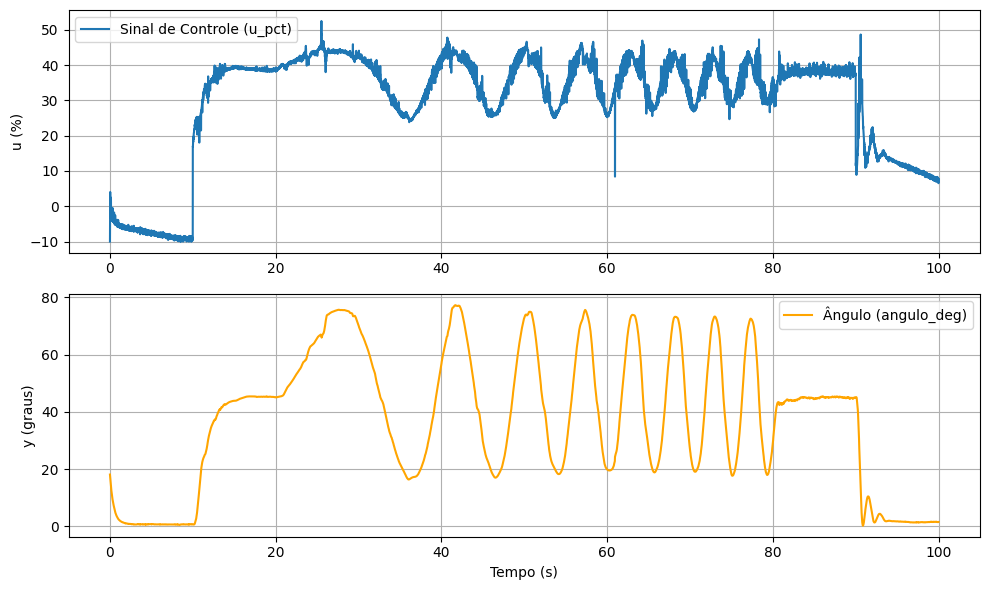

In [3]:
# Carregando o arquivo CSV (Ajuste o caminho se necessário)
file_path = 'sinal3_swept_sine_malha_fechada.csv'
df = pd.read_csv(file_path)

t = df['tempo_ms'].values / 1000.0
u_raw = df['u_pct'].values
y_raw = df['angulo_deg'].values

Ts = np.mean(np.diff(t))
print(f'Ts estimado: {Ts:.3f} s')

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, u, label='Sinal de Controle (u_pct)')
plt.ylabel('u (%)')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, y, label='Ângulo (angulo_deg)', color='orange')
plt.xlabel('Tempo (s)')
plt.ylabel('y (graus)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2. Divisão em Treino e Teste
Vamos separar a primeira parte dos dados para identificação (Treino) e o restante para validação cruzada (Teste).

In [4]:
N = len(u)
split_idx = int(0.7 * N) # 70% para treino, 30% para teste

u_train, y_train = u[:split_idx], y[:split_idx]
u_test, y_test = u[split_idx:], y[split_idx:]
t_train, t_test = t[:split_idx], t[split_idx:]

print(f'Total de amostras: {N}')
print(f'Amostras de Treino: {len(u_train)}')
print(f'Amostras de Teste: {len(u_test)}')

Total de amostras: 10001
Amostras de Treino: 7000
Amostras de Teste: 3001


## 3. Identificação do Sistema (Batch Least Squares)
Vamos identificar um modelo ARX discreto de segunda ordem. A estrutura do modelo será:
$$y(k) = -a_1 y(k-1) - a_2 y(k-2) + b_1 u(k-1) + b_2 u(k-2)$$

A matriz regressora $\Phi$ será composta por estes termos atrasados e os parâmetros $\theta = [a_1, a_2, b_1, b_2]^T$.

In [8]:
def construct_phi(y_data, u_data):
    N_data = len(y_data)
    y_k_minus_1 = -y_data[1:N_data-1]
    y_k_minus_2 = -y_data[0:N_data-2]
    u_k_minus_1 =  u_data[1:N_data-1]
    u_k_minus_2 =  u_data[0:N_data-2]

    Phi = np.column_stack((y_k_minus_1, y_k_minus_2, u_k_minus_1, u_k_minus_2))
    Y_target = y_data[2:N_data]
    return Phi, Y_target

Phi_TRAIN, Y_target_TRAIN = construct_phi(y_train, u_train)
theta_hat, residuals, rank, singular_values = np.linalg.lstsq(Phi_TRAIN, Y_target_TRAIN, rcond=None)

print('Parâmetros Estimados [a1, a2, b1, b2]:')
print(theta_hat)

Parâmetros Estimados [a1, a2, b1, b2]:
[-1.91589624e+00  9.16194740e-01  2.69145777e-04  1.35838243e-04]


## 4. Avaliação (Predição One-Step-Ahead)
A predição um-passo-à-frente (OSA) utiliza os valores reais passados para prever o valor atual. Isso avalia o quão bem a equação consegue calcular o próximo ponto.

In [12]:
# Predição no conjunto de treino
yhat_TRAIN = Phi_TRAIN @ theta_hat

# Matriz Phi para teste
Phi_TEST, Y_target_TEST = construct_phi(y_test, u_test)

# Predição no conjunto de teste
yhat_TEST = Phi_TEST @ theta_hat

# Plot Treino
plt.figure(figsize=(10, 4))
plt.plot(t_train[2:], Y_target_TRAIN, label='Medido (Treino)')
plt.plot(t_train[2:], yhat_TRAIN, label='Predição OSA (Treino)', linestyle='--')
plt.title('Fase de Treino: Saída e Predição One-Step-Ahead')
plt.xlabel('Tempo (s)')
plt.ylabel('y (graus)')
plt.legend()
plt.grid(True)
plt.show()

# Plot Teste
plt.figure(figsize=(10, 4))
plt.plot(t_test[2:], Y_target_TEST, label='Medido (Teste)')
plt.plot(t_test[2:], yhat_TEST, label='Predição OSA (Teste)', linestyle='--')
plt.title('Fase de Teste: Saída e Predição One-Step-Ahead')
plt.xlabel('Tempo (s)')
plt.ylabel('y (graus)')
plt.legend()
plt.grid(True)
plt.show()

Parâmetros Estimados [a1, a2, b1, b2]:
[-1.91589624e+00  9.16194740e-01  2.69145777e-04  1.35838243e-04]


## 5. Simulando a Malha Aberta Completa (Free-Run Simulation)
Diferente do One-Step-Ahead, na simulação livre (free run) o modelo não recebe mais os valores reais de $y(k-1)$ e $y(k-2)$. Ele tem que usar as suas próprias estimativas passadas $\hat{y}(k-1)$ e $\hat{y}(k-2)$. Este é o teste definitivo da validade do modelo!

In [11]:
def simulate_model(u_data, theta, y_initial_1, y_initial_2):
    a1, a2, b1, b2 = theta
    y_sim = np.zeros(len(u_data))

    # Setando as condições iniciais com os valores reais (sem média)
    y_sim[0] = y_initial_1
    y_sim[1] = y_initial_2

    for k in range(2, len(u_data)):
        y_sim[k] = -a1 * y_sim[k-1] - a2 * y_sim[k-2] + b1 * u_data[k-1] + b2 * u_data[k-2]

    return y_sim

# Simulando com as condições iniciais corretas de teste
y_sim_test_centered = simulate_model(u_test, theta_hat, y_test[0], y_test[1])

# Devolvendo o Ponto de Operação (Média) para o gráfico
y_sim_test_real = y_sim_test_centered + y_mean

plt.figure(figsize=(10, 4))
plt.plot(t_test, y_test_raw, label='Medido Real (Teste)')
plt.plot(t_test, y_sim_test_real, label='Simulação Livre (Corrigida)', linestyle='--')
plt.title('Fase de Teste: Simulação de Malha Aberta (Free Run) Melhorada')
plt.xlabel('Tempo (s)')
plt.ylabel('y (graus)')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'y_mean' is not defined